# Delivery ETA Prediction — XGBoost Regressor
**Goals:**
- Predict `delivery_time_hours` (ETA) for any shipment
- Works with partial inputs (missing features handled by imputers)
- ETA estimator function for live order inputs
- Writes predictions back to TiDB Cloud
- SQL views & Power BI friendly exports

## 1. Install dependencies

In [ ]:
!pip install xgboost scikit-learn pandas numpy sqlalchemy pymysql python-dotenv --quiet
# TiDB Cloud requires SSL; cryptography is needed by PyMySQL for TLS
!pip install cryptography --quiet

## 2. Load data

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load CSV
CSV_PATH = '../data/Delivery_Logistics.csv'

df = pd.read_csv(CSV_PATH)

# Normalise column names (lowercase + strip spaces)
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

print('Shape:', df.shape)
df.head(3)

Shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700


## 3. TiDB Cloud connection (same as delay notebook)

In [2]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()  # reads .env from the current working directory

import ssl, platform

# Auto-detect CA bundle path by OS
_ca_paths = {
    "Linux":   "/etc/ssl/certs/ca-certificates.crt",
    "Darwin":  "/etc/ssl/cert.pem",
    "Windows": "C:/Windows/System32/curl-ca-bundle.crt",
}

CA_CERT = os.getenv("TIDB_CA_CERT", _ca_paths.get(platform.system(), "/etc/ssl/certs/ca-certificates.crt"))

connect_args = {
    "ssl": {
        "ca": CA_CERT,
    }
}

from urllib.parse import quote_plus

engine = create_engine(
    f"mysql+pymysql://"
    f"{quote_plus(os.getenv('MYSQL_USER'))}:"
    f"{quote_plus(os.getenv('MYSQL_PASSWORD'))}@"
    f"{os.getenv('MYSQL_HOST')}:"
    f"{os.getenv('MYSQL_PORT', '4000')}/"
    f"{os.getenv('MYSQL_DB')}",
    connect_args=connect_args,
    pool_pre_ping=True,
    pool_recycle=1800,
)

# Quick connectivity test
with engine.connect() as conn:
    print("TiDB Cloud connected ✅")

TiDB Cloud connected ✅


## 4. Load data from TiDB Cloud (or fall back to CSV)

In [3]:
try:
    df = pd.read_sql("SELECT * FROM delivery_logistics", engine)
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    print('Loaded from TiDB Cloud. Shape:', df.shape)
except Exception as e:
    print(f'TiDB read failed ({e}), using CSV instead.')
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
    print('Using CSV data. Shape:', df.shape)

df.head(3)

Loaded from TiDB Cloud. Shape: (24502, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206
1,251.00,blue dart,cosmetics,truck,express,west,hot,74.1,28.64,3,3,yes,failed,1,506.4200
2,252.00,fedex,pharmacy,bike,express,west,cold,58.9,11.97,2,3,no,delivered,3,380.4100


## 5. Feature engineering & preprocessing

In [ ]:
# ── Cast numeric columns ─────────────────────────────────────────────────────
for col in ['delivery_time_hours', 'expected_time_hours', 'distance_km',
            'package_weight_kg', 'delivery_cost', 'delivery_rating', 'delivery_id']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Target: actual delivery time in hours ────────────────────────────────────
TARGET = 'delivery_time_hours'

# Drop rows where target is missing
df = df.dropna(subset=[TARGET])
print(f'Rows after dropping missing target: {len(df)}')

# ── Feature columns ──────────────────────────────────────────────────────────

#  expected_time_hours is a known input at booking time, so it IS a valid feature.
CATEGORICAL = ['delivery_partner', 'package_type', 'vehicle_type',
               'delivery_mode', 'region', 'weather_condition']

NUMERIC     = ['distance_km', 'package_weight_kg',
               'expected_time_hours', 'delivery_cost']

ALL_FEATURES = CATEGORICAL + NUMERIC

print('Features:', ALL_FEATURES)
print('\nTarget stats:')
print(df[TARGET].describe())

Rows after dropping missing target: 24502
Features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost']

Target stats:
count    24502.000000
mean         6.249816
std          3.141519
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         19.000000
Name: delivery_time_hours, dtype: float64


## 6. Build regression pipeline

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

# Categorical: impute with 'Unknown', then ordinal-encode
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Numeric: impute with median
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, CATEGORICAL),
    ('num', num_pipeline, NUMERIC)
])

eta_model = Pipeline([
    ('prep', preprocessor),
    ('reg',  XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric='rmse',
                random_state=42
    ))
])

print('ETA regression pipeline ready.')

ETA regression pipeline ready.


## 7. Train / Test split & evaluation

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

eta_model.fit(X_train, y_train)

y_pred = eta_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  (Mean Absolute Error) : {mae:.3f} hours')
print(f'RMSE (Root Mean Sq. Error) : {rmse:.3f} hours')
print(f'R²   (Explained Variance)  : {r2:.4f}')

MAE  (Mean Absolute Error) : 1.307 hours
RMSE (Root Mean Sq. Error) : 1.660 hours
R²   (Explained Variance)  : 0.7237


## 8. Feature importance

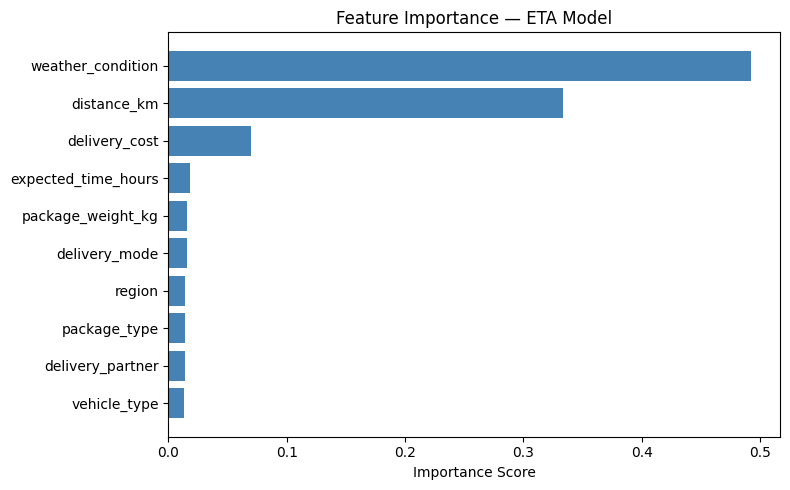

            feature  importance
  weather_condition    0.492119
        distance_km    0.333003
      delivery_cost    0.070034
expected_time_hours    0.017901
  package_weight_kg    0.016019
      delivery_mode    0.015593
             region    0.014376
       package_type    0.013803
   delivery_partner    0.013650
       vehicle_type    0.013502


In [7]:
import matplotlib.pyplot as plt

feat_names = CATEGORICAL + NUMERIC
importances = eta_model.named_steps['reg'].feature_importances_

fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_title('Feature Importance — ETA Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.sort_values('importance', ascending=False).to_string(index=False))

## 9. ETA estimator function (partial input supported)

In [8]:
def estimate_eta(user_input: dict) -> dict:
    """
    Estimate delivery ETA given any subset of known features.
    Missing features are left as NaN — the imputers handle them.

    Parameters
    ----------
    user_input : dict
        Any combination of keys from ALL_FEATURES.
        e.g. {'region': 'north', 'distance_km': 350, 'weather_condition': 'rainy'}

    Returns
    -------
    dict with predicted_eta_hours, lower_bound, upper_bound (±MAE confidence)
    """
    row = {col: np.nan for col in ALL_FEATURES}
    row.update(user_input)

    input_df = pd.DataFrame([row], columns=ALL_FEATURES)
    eta_hours = float(eta_model.predict(input_df)[0])

    # Confidence window: ±1 MAE
    return {
        'predicted_eta_hours': round(eta_hours, 2),
        'lower_bound_hours':   round(max(0, eta_hours - mae), 2),
        'upper_bound_hours':   round(eta_hours + mae, 2),
    }


# ── Demo ────────────────────────────────────────────────────────────────────
demo_result = estimate_eta({
    'region':            'north',
    'distance_km':       350,
    'weather_condition': 'rainy',
    'vehicle_type':      'truck'
})

print('ETA Estimate:')
for k, v in demo_result.items():
    print(f'  {k}: {v} hrs')

ETA Estimate:
  predicted_eta_hours: 9.02 hrs
  lower_bound_hours: 7.71 hrs
  upper_bound_hours: 10.32 hrs


## 10. More estimation examples

In [9]:
# Minimal input — only region and distance
print(estimate_eta({'region': 'south', 'distance_km': 120}))

# Express mode with known partner
print(estimate_eta({
    'delivery_partner': 'delhivery',
    'delivery_mode':    'express',
    'distance_km':      80,
    'package_weight_kg': 2.5
}))

# Full feature set
print(estimate_eta({
    'delivery_partner':  'dhl',
    'package_type':      'electronics',
    'vehicle_type':      'ev van',
    'delivery_mode':     'same day',
    'region':            'east',
    'weather_condition': 'clear',
    'distance_km':       200,
    'package_weight_kg': 5.0,
    'expected_time_hours': 6,
    'delivery_cost':     900
}))

{'predicted_eta_hours': 3.83, 'lower_bound_hours': 2.52, 'upper_bound_hours': 5.14}
{'predicted_eta_hours': 3.4, 'lower_bound_hours': 2.09, 'upper_bound_hours': 4.71}
{'predicted_eta_hours': 5.83, 'lower_bound_hours': 4.53, 'upper_bound_hours': 7.14}


## 11. Score the full dataset & write ETA predictions to TiDB Cloud

In [10]:
# Score full dataset
df['predicted_eta_hours'] = eta_model.predict(df[ALL_FEATURES]).round(2)
df['eta_error_hours']     = (df['predicted_eta_hours'] - df[TARGET]).round(2)
df['eta_error_pct']       = ((df['eta_error_hours'] / df[TARGET]) * 100).round(2)

# Columns to export — clean for SQL / Power BI
EXPORT_COLS = [
    'delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
    'delivery_mode', 'region', 'weather_condition',
    'distance_km', 'package_weight_kg', 'delivery_cost',
    'expected_time_hours', 'delivery_time_hours',
    'predicted_eta_hours', 'eta_error_hours', 'eta_error_pct'
]

eta_output_df = df[EXPORT_COLS].copy()

print(eta_output_df.head(3))
print('\nShape:', eta_output_df.shape)

   delivery_id delivery_partner      package_type vehicle_type delivery_mode  \
0       250.99        delhivery  automobile parts         bike      same day   
1       251.00        blue dart         cosmetics        truck       express   
2       252.00            fedex          pharmacy         bike       express   

  region weather_condition  distance_km  package_weight_kg  delivery_cost  \
0   west             clear        297.0              46.96      1632.7206   
1   west               hot         74.1              28.64       506.4200   
2   west              cold         58.9              11.97       380.4100   

   expected_time_hours  delivery_time_hours  predicted_eta_hours  \
0                    8                    8                 8.16   
1                    3                    3                 2.91   
2                    3                    2                 2.57   

   eta_error_hours  eta_error_pct  
0             0.16            2.0  
1            -0.09       

In [13]:
# Score full dataset
df['predicted_eta_hours'] = eta_model.predict(df[ALL_FEATURES]).round(2)
df['eta_error_hours']     = (df['predicted_eta_hours'] - df[TARGET]).round(2)

# ── Fix: division by zero produces inf — replace with None (NULL in MySQL) ──
df['eta_error_pct'] = (
    df['eta_error_hours'] / df[TARGET].replace(0, np.nan) * 100
).round(2)

# Sanitise: replace inf / -inf with NaN so MySQL accepts them as NULL
import math
numeric_cols = ['predicted_eta_hours', 'eta_error_hours', 'eta_error_pct',
                'distance_km', 'package_weight_kg', 'delivery_cost',
                'expected_time_hours', 'delivery_time_hours', 'delivery_id']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

# Build export dataframe
EXPORT_COLS = [
    'delivery_id', 'delivery_partner', 'package_type', 'vehicle_type',
    'delivery_mode', 'region', 'weather_condition',
    'distance_km', 'package_weight_kg', 'delivery_cost',
    'expected_time_hours', 'delivery_time_hours',
    'predicted_eta_hours', 'eta_error_hours', 'eta_error_pct'
]
eta_output_df = df[EXPORT_COLS].copy()

# Cast all numeric cols to float so SQLAlchemy uses FLOAT not BIGINT
from sqlalchemy import Float
dtype_map = {c: Float for c in numeric_cols if c in EXPORT_COLS}

eta_output_df.to_sql(
    name='delivery_eta_predictions',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=200,
    method='multi',
    dtype=dtype_map,
)
print('Written to TiDB Cloud table: delivery_eta_predictions ✅')

Written to TiDB Cloud table: delivery_eta_predictions ✅


## 12. MySQL-friendly SQL views

Once the `delivery_eta_predictions` table exists in TiDB Cloud, run these in SQLTools:

```sql
-- Average predicted ETA vs actual by partner
SELECT
    delivery_partner,
    COUNT(*)                                        AS total_deliveries,
    ROUND(AVG(delivery_time_hours), 2)              AS avg_actual_eta_hrs,
    ROUND(AVG(predicted_eta_hours), 2)              AS avg_predicted_eta_hrs,
    ROUND(AVG(ABS(eta_error_hours)), 2)             AS avg_abs_error_hrs
FROM delivery_eta_predictions
GROUP BY delivery_partner
ORDER BY avg_abs_error_hrs;

-- ETA accuracy by region and weather
SELECT
    region,
    weather_condition,
    ROUND(AVG(predicted_eta_hours), 2)  AS avg_predicted_eta_hrs,
    ROUND(AVG(ABS(eta_error_pct)), 2)   AS avg_abs_error_pct
FROM delivery_eta_predictions
GROUP BY region, weather_condition
ORDER BY avg_abs_error_pct DESC;

-- High ETA error deliveries (off by more than 3 hours)
SELECT *
FROM delivery_eta_predictions
WHERE ABS(eta_error_hours) > 3
ORDER BY ABS(eta_error_hours) DESC;

-- ETA vs actual by delivery mode
SELECT
    delivery_mode,
    ROUND(AVG(delivery_time_hours), 2)   AS avg_actual_hrs,
    ROUND(AVG(predicted_eta_hours), 2)   AS avg_predicted_hrs,
    ROUND(AVG(eta_error_pct), 2)         AS avg_error_pct
FROM delivery_eta_predictions
GROUP BY delivery_mode
ORDER BY avg_actual_hrs;
```

## 13. Save the trained ETA model (optional)

In [16]:
import joblib

joblib.dump(eta_model, '../models/eta_model.pkl')
print('ETA model saved → eta_model.pkl')

# To reload:
# eta_model = joblib.load('eta_model.pkl')

ETA model saved → eta_model.pkl


## 14. Quick re-use demo — single shipment prediction

In [17]:
new_shipment = {
    'delivery_partner':  'shadowfax',
    'package_type':      'groceries',
    'vehicle_type':      'bike',
    'delivery_mode':     'same day',
    'region':            'west',
    'weather_condition': 'foggy',
    'distance_km':       95,
    'package_weight_kg': 3.2,
    'expected_time_hours': 4,
    'delivery_cost':     420
}

result = estimate_eta(new_shipment)

print('=== ETA Prediction ===')
print(f"Predicted ETA  : {result['predicted_eta_hours']} hours")
print(f"Confidence Band: {result['lower_bound_hours']} – {result['upper_bound_hours']} hours")

=== ETA Prediction ===
Predicted ETA  : 5.07 hours
Confidence Band: 3.77 – 6.38 hours


## 15. Verify predictions in TiDB Cloud

In [ ]:
df_sql = pd.read_sql(
    "SELECT * FROM delivery_eta_predictions LIMIT 10;",
    engine
)
print(df_sql.head())